In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class FeedForwardNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FeedForwardNetwork, self).__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),  # Add dropout here
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.ffn(x)

class SimpleVATTEmotionPredictor(nn.Module):
    def __init__(self, audio_dim, text_dim, video_dim, common_space_dim, hidden_dim, num_classes):
        super(SimpleVATTEmotionPredictor, self).__init__()

        self.audio_ffn = FeedForwardNetwork(audio_dim, hidden_dim)
        self.text_ffn = FeedForwardNetwork(text_dim, hidden_dim)
        self.video_ffn = FeedForwardNetwork(video_dim, hidden_dim)

       # Projection heads for common spaces
        self.video_to_va = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )


        self.audio_to_va = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.text_to_vt = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.video_to_vt = nn.Sequential(
            nn.Linear(common_space_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 4, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),  # Add dropout here
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),        # Added missing activation function
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, video_features, audio_features, text_features):
        audio_features = F.dropout(audio_features, p=0.2, training=self.training)
        video_features = F.dropout(video_features, p=0.2, training=self.training)
        text_features = F.dropout(text_features, p=0.2, training=self.training)
        audio_hidden = self.audio_ffn(audio_features)
        text_hidden = self.text_ffn(text_features)

        video_hidden = self.video_ffn(video_features)

        # Project features into common spaces
        z_v_va = self.video_to_va(video_hidden)
        z_a_va = self.audio_to_va(audio_hidden)
        z_t_vt = self.text_to_vt(text_hidden)
        z_v_vt = self.video_to_vt(z_v_va)

        # Concatenate the common space outputs
        combined_embedding = torch.cat([z_v_va, z_a_va, z_v_vt, z_t_vt], dim=-1)

        emotion_logits = self.classifier(combined_embedding)

        return emotion_logits

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Shared components used by the Ensemble, Attentional, and BiM sections below ---
# ( avoid duplicate class defs and
# cell-order dependencies - everything downstream can now safely reuse these.)

class FeedForwardNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FeedForwardNetwork, self).__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.ffn(x)


class AttentionalVATTEmotionPredictor(nn.Module):
    def __init__(self, audio_dim, text_dim, video_dim, common_space_dim, hidden_dim, num_classes, num_heads=4):
        super(AttentionalVATTEmotionPredictor, self).__init__()

        # Feature Extractors
        self.audio_ffn = FeedForwardNetwork(audio_dim, hidden_dim)
        self.text_ffn = FeedForwardNetwork(text_dim, hidden_dim)
        self.video_ffn = FeedForwardNetwork(video_dim, hidden_dim)

        # Projection heads for common spaces
        self.video_to_va = nn.Sequential(nn.Linear(hidden_dim, common_space_dim), nn.BatchNorm1d(common_space_dim))
        self.audio_to_va = nn.Sequential(nn.Linear(hidden_dim, common_space_dim), nn.BatchNorm1d(common_space_dim))
        self.text_to_vt  = nn.Sequential(nn.Linear(hidden_dim, common_space_dim), nn.BatchNorm1d(common_space_dim))
        self.video_to_vt = nn.Sequential(nn.Linear(common_space_dim, common_space_dim), nn.BatchNorm1d(common_space_dim))

        # Genuine cross-modal attention: a real length-3 sequence (one "token" per
        # modality), so the model actually learns to weigh modalities against
        # each other (a length-1 sequence, as in the original version, makes
        # softmax attention collapse to a no-op).
        self.cross_attention = nn.MultiheadAttention(embed_dim=common_space_dim, num_heads=num_heads, dropout=0.3)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, video_features, audio_features, text_features):
        audio_features = F.dropout(audio_features, p=0.2, training=self.training)
        video_features = F.dropout(video_features, p=0.2, training=self.training)
        text_features  = F.dropout(text_features, p=0.2, training=self.training)

        audio_hidden = self.audio_ffn(audio_features)
        text_hidden  = self.text_ffn(text_features)
        video_hidden = self.video_ffn(video_features)

        z_v_va = self.video_to_va(video_hidden)
        z_a_va = self.audio_to_va(audio_hidden)
        z_t_vt = self.text_to_vt(text_hidden)
        z_v_vt = self.video_to_vt(z_v_va)

        modal_seq = torch.stack([z_v_va, z_a_va, z_t_vt], dim=0)   # (3, batch, common_space_dim)
        attn_output, _ = self.cross_attention(modal_seq, modal_seq, modal_seq)
        attn_pooled = attn_output.mean(dim=0)

        z_multimodal = (z_v_va + z_a_va + z_t_vt) / 3.0
        combined_embedding = torch.cat([attn_pooled, z_multimodal], dim=-1)

        emotion_logits = self.classifier(combined_embedding)
        return emotion_logits, z_v_va, z_a_va, z_v_vt, z_t_vt


class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (Khosla et al., 2020) adapted for aligning two
    modalities: pulls together embeddings sharing the same emotion label
    (whether from modality A or B), rather than only self-pairs (as in plain
    InfoNCE). This matters here because with 5 classes and batch_size=32, many
    "negatives" in a batch legitimately share the anchor's true label - plain
    InfoNCE would push those apart, fighting the classifier.
    """
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features_a, features_b, labels):
        device = features_a.device
        features_a = F.normalize(features_a, dim=1)
        features_b = F.normalize(features_b, dim=1)

        features = torch.cat([features_a, features_b], dim=0)
        combined_labels = torch.cat([labels, labels], dim=0)

        sim_matrix = torch.matmul(features, features.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True)[0].detach()

        n = features.shape[0]
        self_mask = torch.eye(n, device=device).bool()

        label_eq = combined_labels.unsqueeze(0) == combined_labels.unsqueeze(1)
        positive_mask = label_eq & ~self_mask

        exp_sim = torch.exp(sim_matrix) * (~self_mask)
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_counts = positive_mask.sum(dim=1)
        valid = positive_counts > 0
        mean_log_prob_pos = (positive_mask * log_prob).sum(dim=1)[valid] / positive_counts[valid]

        return -mean_log_prob_pos.mean()


def make_warmup_then_plateau(optimizer, warmup_epochs=5, plateau_factor=0.5, plateau_patience=7):
    """Shared helper: linear LR warmup for `warmup_epochs`, then ReduceLROnPlateau.
    Call warmup_scheduler.step() while epoch < warmup_epochs, otherwise
    plateau_scheduler.step(avg_val_loss)."""
    warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e + 1) / warmup_epochs))
    plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=plateau_factor, patience=plateau_patience)
    return warmup_scheduler, plateau_scheduler

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import os
# Load datasets

video_df = pd.read_csv("/content/drive/MyDrive/Embedding /video_embeddings_transformer_1.csv")
audio_df = pd.read_csv("/content/drive/MyDrive/audio_features_wave2vec2.csv")
text_df = pd.read_csv("/content/drive/MyDrive/urdu_embeddings_from_tuned_xlmr_final.csv")


# Extract filenames only

audio_df = audio_df.rename(columns={'Link': 'Link_audio'})
video_df = video_df.rename(columns={'Link': 'Link_video'})
text_df = text_df.rename(columns={'Link': 'Link_text'})


video_df["ID"] = video_df["Link_video"].apply(lambda x: os.path.splitext(os.path.basename(str(x)))[0].strip())
audio_df["ID"] = audio_df["Link_audio"].apply(lambda x: os.path.splitext(os.path.basename(str(x)))[0].strip())
text_df["ID"] = text_df["Link_text"].apply(lambda x: os.path.splitext(os.path.basename(str(x)))[0].strip())

# Drop duplicates to prevent shape explosion during merge
text_df = text_df.drop_duplicates(subset="ID", keep="first")
video_df = video_df.drop_duplicates(subset="ID", keep="first")
audio_df = audio_df.drop_duplicates(subset="ID", keep="first")

# Labels rename rules
audio_df = audio_df.rename(columns={'Label': 'Label_audio'})
video_df = video_df.rename(columns={'Target': 'Label_video'})
text_df = text_df.rename(columns={'Label': 'Label_text'})


# Check sample IDs

print("\n Sample IDs Check:")
print("Video ID Sample:", video_df["ID"].iloc[0] if not video_df.empty else "Empty")
print("Audio ID Sample:", audio_df["ID"].iloc[0] if not audio_df.empty else "Empty")
print("Text ID Sample:", text_df["ID"].iloc[0] if not text_df.empty else "Empty")


# Merge datasets

print("\n Merging Modalities...")
merged_df = video_df.merge(audio_df, on="ID", suffixes=("_video", "_audio"))
merged_df = merged_df.merge(text_df, on="ID")


# Final verification check

print(" Merged shape:", merged_df.shape)

if len(merged_df) > 0:
    print("Success!")
else:
    print("Error:")


 Sample IDs Check:
Video ID Sample: Anger_39_2022.278857-2030.965305_Muqaddar Ka Sitara Episode 30 _ 17th January 2023 (Subtitles English) _ ARY Digital
Audio ID Sample: Neutral_11_1529.742919-1534.099763_OPPO presents Suno Chanda Season 9
Text ID Sample: Anger_102_0-6.625516_Anger_15_1756.088005-1787.183652_Muqaddar Ka Sitara Episode 8 _ 26th December 2022 (English Subtitles) _ ARY Digital

 Merging Modalities...
 Merged shape: (8268, 2055)
Success!


In [5]:
video_ids = set(video_df["ID"])
audio_ids = set(audio_df["ID"])
text_ids = set(text_df["ID"])

common_ids = video_ids & audio_ids & text_ids

print("Common IDs:", len(common_ids))

Common IDs: 8268


In [6]:
print(merged_df['Label_video'].value_counts())
print(merged_df['Label_audio'].value_counts())
print(merged_df['Label_text'].value_counts())

Label_video
0    2070
1    1774
3    1657
4    1632
2    1135
Name: count, dtype: int64
Label_audio
A    2070
H    1774
N    1657
S    1630
L    1135
s       2
Name: count, dtype: int64
Label_text
Anger      2070
Happy      1774
Neutral    1657
Sad        1632
Love       1135
Name: count, dtype: int64


In [7]:
import pandas as pd

emotion_mapping = {
    'A': 'Anger',
    'H': 'Happy',
    'N': 'Neutral',
    'S': 'Sad',
    's': 'Sad',
    'L': 'Love'
}
video_mapping = {0: 'Anger', 1: 'Happy', 2: 'Love', 3: 'Neutral', 4: 'Sad'}
merged_df['audio_emotion'] = merged_df['Label_audio'].map(emotion_mapping)
merged_df['video_emotion'] = merged_df['Label_video'].map(video_mapping)

print(merged_df['audio_emotion'].value_counts())
print(merged_df['video_emotion'].value_counts())

audio_emotion
Anger      2070
Happy      1774
Neutral    1657
Sad        1632
Love       1135
Name: count, dtype: int64
video_emotion
Anger      2070
Happy      1774
Neutral    1657
Sad        1632
Love       1135
Name: count, dtype: int64


In [8]:
mismatched = merged_df[
    (merged_df['video_emotion'] != merged_df['audio_emotion']) |
    (merged_df['video_emotion'] != merged_df['Label_text'])
]

print(f"Total rows checking: {len(merged_df)}")
print(f"Mismatched rows : {len(mismatched)}")

if len(mismatched) > 0:
    import pandas as pd
    pd.set_option('display.max_colwidth', None)

    print("\n======= MISMATCHED SAMPLES REPORT =======")
    print(mismatched[['ID', 'video_emotion', 'audio_emotion', 'Label_text']].head(30))
else:
    print("\n now labels matched perfectly!")

Total rows checking: 8268
Mismatched rows : 0

 now labels matched perfectly!


In [9]:
import torch
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- FIX (#1): robust feature column selection ---
# Relying only on pandas' automatic "_x"/"_y" merge-suffixing is fragile: it only
# fires for column names that happen to collide between merged_df and text_df.
# Any feature column that DOESN'T collide silently gets excluded with no warning.
# We now match on explicit naming prefixes first, and fall back to the merge-suffix
# behavior only as a safety net. ALWAYS check the printed counts below against the
# expected embedding dimensionality of your CSVs before trusting the split.
feature_columns_video = [col for col in merged_df.columns if col.startswith('E_') or col.endswith('_x')]
feature_columns_audio = [col for col in merged_df.columns if col.startswith('Feature_') or col.startswith('F_')]
feature_columns_text  = [col for col in merged_df.columns if col.isdigit() or col.endswith('_y')]

print("Feature column diagnostic (verify these match your expected embedding dims!):")
print(f"  Video feature columns: {len(feature_columns_video)} -> sample: {feature_columns_video[:5]}")
print(f"  Audio feature columns: {len(feature_columns_audio)} -> sample: {feature_columns_audio[:5]}")
print(f"  Text  feature columns: {len(feature_columns_text)} -> sample: {feature_columns_text[:5]}")

# Labels should be handled separately
labels = merged_df['Label_video'].values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# NOTE (#3): class weights are now computed AFTER the train/test split (see next cell),
# using y_train only, so validation/test label distribution can't leak into training.

# Prepare features and labels
X_video = merged_df[feature_columns_video].values
X_audio = merged_df[feature_columns_audio].values
X_text = merged_df[feature_columns_text].values

# Convert to tensors
X_video_tensor = torch.tensor(X_video, dtype=torch.float32)
X_audio_tensor = torch.tensor(X_audio, dtype=torch.float32)
X_text_tensor = torch.tensor(X_text, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# Print shapes to verify
print(f"Video features tensor shape: {X_video_tensor.shape}")
print(f"Audio features tensor shape: {X_audio_tensor.shape}")
print(f"Text features tensor shape: {X_text_tensor.shape}")
print(f"Labels tensor shape: {y_tensor.shape}")

Feature column diagnostic (verify these match your expected embedding dims!):
  Video feature columns: 256 -> sample: ['0_x', '1_x', '2_x', '3_x', '4_x']
  Audio feature columns: 1024 -> sample: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
  Text  feature columns: 768 -> sample: ['0_y', '1_y', '2_y', '3_y', '4_y']
Video features tensor shape: torch.Size([8268, 256])
Audio features tensor shape: torch.Size([8268, 1024])
Text features tensor shape: torch.Size([8268, 768])
Labels tensor shape: torch.Size([8268])


In [10]:
X_video_tensor.shape

torch.Size([8268, 256])

In [11]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
# Train-Test-Validation split
from sklearn.model_selection import train_test_split

X_audio_train, X_audio_test, X_video_train, X_video_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_audio_tensor.numpy(), X_video_tensor.numpy(), X_text_tensor.numpy(), y_tensor.numpy(), test_size=0.2, random_state=42,stratify=y_tensor.numpy()
)

X_audio_val, X_audio_test, X_video_val, X_video_test, X_text_val, X_text_test, y_val, y_test = train_test_split(
    X_audio_test, X_video_test, X_text_test, y_test, test_size=0.5, random_state=42,stratify=y_test
)

# --- FIX (#3): class weights computed from TRAINING labels only, not the full dataset ---
# (this avoids leaking val/test class distribution into the training loss)
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights (from y_train only):", dict(zip(label_encoder.inverse_transform(classes), class_weights)))

batch_size = 32

scaler_audio = StandardScaler()
X_audio_train_scaled = scaler_audio.fit_transform(X_audio_train)
X_audio_val_scaled = scaler_audio.transform(X_audio_val)
X_audio_test_scaled = scaler_audio.transform(X_audio_test)

scaler_video = StandardScaler()
X_video_train_scaled = scaler_video.fit_transform(X_video_train)
X_video_val_scaled = scaler_video.transform(X_video_val)
X_video_test_scaled = scaler_video.transform(X_video_test)

scaler_text = StandardScaler()
X_text_train_scaled = scaler_text.fit_transform(X_text_train)
X_text_val_scaled = scaler_text.transform(X_text_val)
X_text_test_scaled = scaler_text.transform(X_text_test)


train_dataset = TensorDataset(torch.tensor(X_audio_train_scaled, dtype=torch.float32),
                              torch.tensor(X_video_train_scaled, dtype=torch.float32),
                              torch.tensor(X_text_train_scaled, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.long))
# --- FIX (#7): drop_last=True avoids a leftover batch of size 1, which would
# crash BatchNorm1d during training (it needs >1 sample to compute batch stats)
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

validation_dataset = TensorDataset(torch.tensor(X_audio_val_scaled, dtype=torch.float32),
                                   torch.tensor(X_video_val_scaled, dtype=torch.float32),
                                   torch.tensor(X_text_val_scaled, dtype=torch.float32),
                                   torch.tensor(y_val, dtype=torch.long))
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(torch.tensor(X_audio_test_scaled, dtype=torch.float32),
                             torch.tensor(X_video_test_scaled, dtype=torch.float32),
                             torch.tensor(X_text_test_scaled, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.long))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Class weights (from y_train only): {np.int64(0): np.float64(0.798792270531401), np.int64(1): np.float64(0.9322057787174066), np.int64(2): np.float64(1.456828193832599), np.int64(3): np.float64(0.9983396226415094), np.int64(4): np.float64(1.012863705972435)}


In [12]:
# --- Data augmentation for minority classes (supervisor suggestion #1) ---# Feature-space augmentation on the SCALED training embeddings only (val/test# are left untouched - augmenting eval data would inflate reported metrics).# For each class with fewer training examples than a target count, we# synthesize new examples by interpolating between two random same-class# training embeddings (mixup-style) and adding a little Gaussian noise. This# is a light-weight stand-in for image/audio-domain augmentation, appropriate# here because we only have pooled embeddings, not raw video/audio/text to# re-augment from scratch.import numpy as npdef augment_minority_classes(X_audio, X_video, X_text, y, target_ratio=0.8, noise_std=0.03, seed=42):    rng = np.random.default_rng(seed)    classes, counts = np.unique(y, return_counts=True)    majority_count = counts.max()    # Don't force full balance (100%) - that tends to overfit the smallest    # class by cloning near-duplicates. 80% of the majority is a gentler target.    target_count = int(majority_count * target_ratio)    aug_audio, aug_video, aug_text, aug_y = [], [], [], []    for cls, cnt in zip(classes, counts):        if cnt >= target_count:            continue        n_needed = target_count - cnt        idx = np.where(y == cls)[0]        for _ in range(n_needed):            i, j = rng.choice(idx, size=2, replace=True)            lam = rng.uniform(0.3, 0.7)  # keep interpolated point away from the originals            a = lam * X_audio[i] + (1 - lam) * X_audio[j]            v = lam * X_video[i] + (1 - lam) * X_video[j]            t = lam * X_text[i]  + (1 - lam) * X_text[j]            a = a + rng.normal(0, noise_std, size=a.shape)            v = v + rng.normal(0, noise_std, size=v.shape)            t = t + rng.normal(0, noise_std, size=t.shape)            aug_audio.append(a); aug_video.append(v); aug_text.append(t); aug_y.append(cls)    if not aug_y:        return X_audio, X_video, X_text, y    X_audio_aug = np.vstack([X_audio, np.array(aug_audio)])    X_video_aug = np.vstack([X_video, np.array(aug_video)])    X_text_aug  = np.vstack([X_text,  np.array(aug_text)])    y_aug       = np.concatenate([y, np.array(aug_y)])    return X_audio_aug, X_video_aug, X_text_aug, y_augprint("Before augmentation:", dict(zip(*np.unique(y_train, return_counts=True))))X_audio_train_scaled, X_video_train_scaled, X_text_train_scaled, y_train = augment_minority_classes(    X_audio_train_scaled, X_video_train_scaled, X_text_train_scaled, y_train)print("After augmentation: ", dict(zip(*np.unique(y_train, return_counts=True))))# --- Rebuild the training DataLoader with the augmented data ---# (validation_loader / test_loader are untouched - still the original,# non-augmented, non-leaked data built in the cell above)train_dataset = TensorDataset(    torch.tensor(X_audio_train_scaled, dtype=torch.float32),    torch.tensor(X_video_train_scaled, dtype=torch.float32),    torch.tensor(X_text_train_scaled, dtype=torch.float32),    torch.tensor(y_train, dtype=torch.long))train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)# --- Recompute class weights from the augmented training set ---# (still balanced-but-softer, since augmentation already reduced the imbalance)classes = np.unique(y_train)class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)print("Updated class weights (post-augmentation):", dict(zip(label_encoder.inverse_transform(classes), class_weights)))

In [13]:
import joblib
import os

drive_path = "/content/drive/MyDrive/UrEMONet_Models/"
os.makedirs(drive_path, exist_ok=True)

joblib.dump(scaler_audio, os.path.join(drive_path, 'scaler_audio.pkl'))
joblib.dump(scaler_video, os.path.join(drive_path, 'scaler_video.pkl'))
joblib.dump(scaler_text,  os.path.join(drive_path, 'scaler_text.pkl'))

print("Scalers successfully saved to Google Drive!")

Scalers successfully saved to Google Drive!


In [14]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model
speech_input_dim = X_audio_train.shape[1]
video_input_dim = X_video_train.shape[1]
video_input_dim = X_video_train.shape[1]
text_input_dim = X_text_train.shape[1]

hidden_dim = 512  # Hidden dimension inside feed-forward networks
common_space_dim = 256  # Common space dimension for video-audio and video-text
num_classes = len(label_encoder.classes_)  # Number of emotion classes

# Instantiate the model
model = SimpleVATTEmotionPredictor(speech_input_dim, text_input_dim, video_input_dim, common_space_dim,hidden_dim, num_classes)
model.to(device)

SimpleVATTEmotionPredictor(
  (audio_ffn): FeedForwardNetwork(
    (ffn): Sequential(
      (0): Linear(in_features=1024, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.4, inplace=False)
      (4): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (text_ffn): FeedForwardNetwork(
    (ffn): Sequential(
      (0): Linear(in_features=768, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.4, inplace=False)
      (4): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (video_ffn): FeedForwardNetwork(
    (ffn): Sequential(
      (0): Linear(in_features=256, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.4, inplace=False)
     

In [15]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
criterion_val = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# LR warmup (5 epochs) + ReduceLROnPlateau afterward (shared helper, defined in the
# "Shared Model Components" cell above)
warmup_scheduler, scheduler = make_warmup_then_plateau(optimizer, warmup_epochs=5, plateau_factor=0.1, plateau_patience=5)

# Training loop
num_epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
validation_accuracies = []

best_val_loss = float('inf')
model_checkpoint_path = 'best_model_simple_vatt.pth'
early_stop_patience = 10
epochs_without_improvement = 0
warmup_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    for speech_features, video_features, text_features, targets in train_data_loader:
        speech_features, video_features, text_features, targets = (
            speech_features.to(device).float(),
            video_features.to(device).float(),
            text_features.to(device).float(),
            targets.to(device)
        )

        optimizer.zero_grad()

        outputs = model(video_features, speech_features, text_features)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted_train = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted_train == targets).sum().item()

    avg_loss = total_loss / len(train_data_loader)
    train_losses.append(avg_loss)

    accuracy_train = correct_train / total_train
    train_accuracies.append(accuracy_train)

    model.eval()
    correct_val = 0
    total_val = 0
    val_loss_total = 0.0

    with torch.no_grad():
        for speech_features, video_features, text_features, targets in validation_loader:
            speech_features, video_features, text_features, targets = (
                speech_features.to(device).float(),
                video_features.to(device).float(),
                text_features.to(device).float(),
                targets.to(device)
            )

            outputs = model(video_features, speech_features, text_features)

            val_loss = criterion_val(outputs, targets)
            val_loss_total += val_loss.item()

            _, predicted_val = torch.max(outputs, 1)

            total_val += targets.size(0)
            correct_val += (predicted_val == targets).sum().item()

    avg_val_loss = val_loss_total / len(validation_loader)
    accuracy_val = correct_val / total_val

    validation_accuracies.append(accuracy_val)

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch [{epoch + 1}/{num_epochs}], LR: {current_lr:.6f}, "
        f"Train Loss: {avg_loss:.4f}, "
        f"Validation Loss: {avg_val_loss:.4f}, "
        f"Train Accuracy: {accuracy_train * 100:.2f}%, "
        f"Validation Accuracy: {accuracy_val * 100:.2f}%"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        print("   --> Validation loss improved, saving model...")
        torch.save(model.state_dict(), model_checkpoint_path)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stop_patience:
            print(f"Early stopping at epoch {epoch + 1} (no improvement for {early_stop_patience} epochs).")
            break

    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        scheduler.step(avg_val_loss)

model.load_state_dict(torch.load(model_checkpoint_path))

model.eval()
correct_test = 0
total_test = 0
test_loss_total = 0.0

with torch.no_grad():
    for speech_features, video_features, text_features, targets in test_loader:
        speech_features, video_features, text_features, targets = (
            speech_features.to(device).float(),
            video_features.to(device).float(),
            text_features.to(device).float(),
            targets.to(device)
        )

        outputs = model(video_features, speech_features, text_features)

        test_loss = criterion_val(outputs, targets)
        test_loss_total += test_loss.item()

        _, predicted_test = torch.max(outputs, 1)

        total_test += targets.size(0)
        correct_test += (predicted_test == targets).sum().item()

accuracy_test = correct_test / total_test
avg_test_loss = test_loss_total / len(test_loader)

print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy_test * 100:.2f}%")

Epoch [1/100], LR: 0.000200, Train Loss: 1.0425, Validation Loss: 0.8131, Train Accuracy: 61.10%, Validation Accuracy: 70.01%
   --> Validation loss improved, saving model...
Epoch [2/100], LR: 0.000400, Train Loss: 0.8740, Validation Loss: 0.8656, Train Accuracy: 67.35%, Validation Accuracy: 68.20%
Epoch [3/100], LR: 0.000600, Train Loss: 0.8625, Validation Loss: 0.7994, Train Accuracy: 68.14%, Validation Accuracy: 68.68%
   --> Validation loss improved, saving model...
Epoch [4/100], LR: 0.000800, Train Loss: 0.8306, Validation Loss: 0.8320, Train Accuracy: 69.63%, Validation Accuracy: 69.89%
Epoch [5/100], LR: 0.001000, Train Loss: 0.8133, Validation Loss: 0.7686, Train Accuracy: 70.62%, Validation Accuracy: 72.19%
   --> Validation loss improved, saving model...
Epoch [6/100], LR: 0.001000, Train Loss: 0.8065, Validation Loss: 0.7516, Train Accuracy: 71.37%, Validation Accuracy: 70.86%
   --> Validation loss improved, saving model...
Epoch [7/100], LR: 0.001000, Train Loss: 0.7676,

In [16]:
import matplotlib.pyplot as plt
def plot_metrics(train_losses, test_losses, train_accuracies, test_accuracies, validation_accuracies=None):
    plt.figure(figsize=(15, 5))
    # Plotting Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    #plt.plot(test_losses, label='Test Loss', color='red')
    if validation_accuracies is not None:
        plt.plot(validation_accuracies, label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plotting Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy', color='blue')
   # plt.plot(test_accuracies, label='Test Accuracy', color='red')
    if validation_accuracies is not None:
        plt.plot(validation_accuracies, label='Validation Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

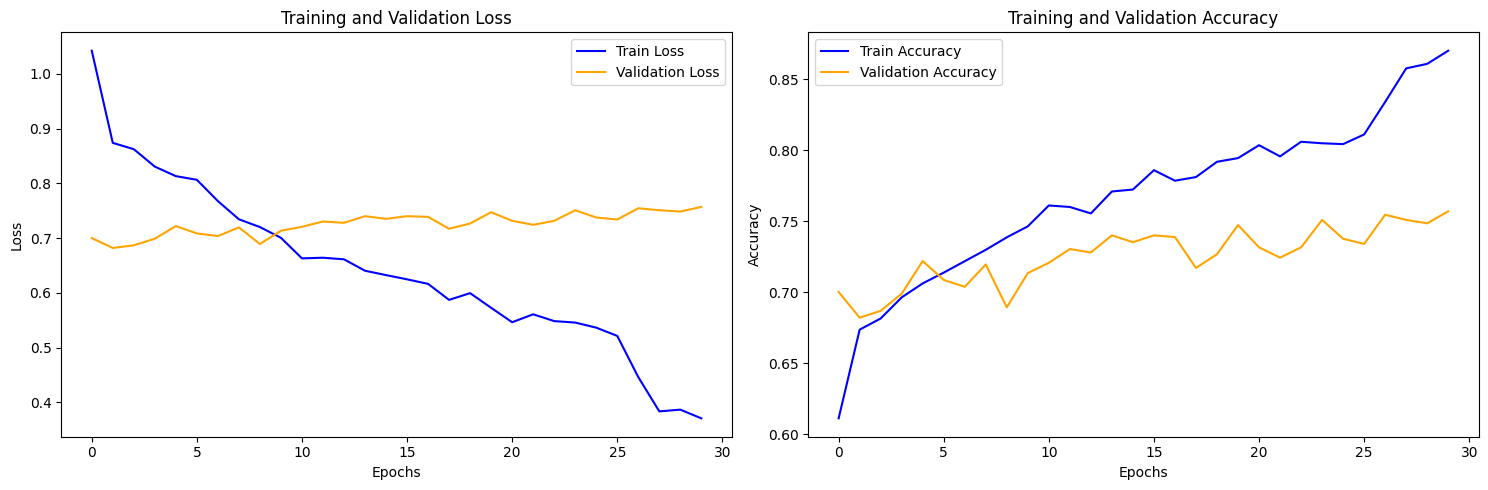

F1 Score: 0.7457
Accuracy: 0.7449
Report :
               precision    recall  f1-score   support

           0       0.87      0.79      0.83       207
           1       0.77      0.75      0.76       178
           2       0.67      0.70      0.68       113
           3       0.65      0.64      0.65       166
           4       0.73      0.82      0.77       163

    accuracy                           0.74       827
   macro avg       0.74      0.74      0.74       827
weighted avg       0.75      0.74      0.75       827



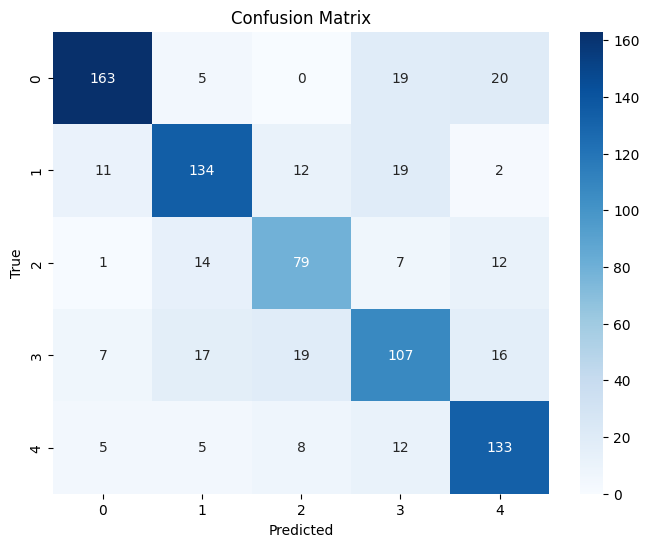

In [17]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Loss and Accuracy
plot_metrics(train_losses, test_losses, train_accuracies, test_accuracies, validation_accuracies)

# Calculate F1 Score
model.eval()
all_predicted = []
all_targets = []

for batch in test_loader:
    # Unpack the batch
    speech_features, video_features, text_features, targets = batch

    # Move data to device
    speech_features, video_features, text_features, targets = (
        speech_features.to(device).float(),
        video_features.to(device).float(),
        text_features.to(device).float(),
        targets.to(device)
    )

    # Forward pass
    outputs = model(video_features, speech_features, text_features)
    _, predicted = torch.max(outputs, 1)

    all_predicted.extend(predicted.cpu().numpy())
    all_targets.extend(targets.cpu().numpy())

# Calculate accuracy
accuracy = sum([1 for i, j in zip(all_predicted, all_targets) if i == j]) / len(all_targets)

f1 = f1_score(all_targets, all_predicted, average='weighted')
print(f"F1 Score: {f1:.4f}")

# Classification Report
report = classification_report(all_targets, all_predicted)
print(f"Accuracy: {accuracy:.4f}")
print("Report :\n", report)

# Confusion Matrix
labels_list = label_encoder.classes_
conf_matrix = confusion_matrix(all_targets, all_predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels_list, yticklabels=labels_list)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# **Ensemble Learning**

In [18]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --- Ensemble diversity + weighted voting ---
# Supervisor feedback: (a) add architecturally diverse members, not just different
# seeds of the same model, and (b) weight members by validation accuracy instead
# of a flat average. Both are implemented below.
#
# Each config: ('simple', seed) trains a SimpleVATTEmotionPredictor.
#              ('attentional', seed) trains the AttentionalVATTEmotionPredictor
#              (with its cross-modal attention + SupCon alignment loss), giving
#              the ensemble genuinely different error patterns to average over.
ensemble_configs = [
    {'name': 'simple_seed42',       'arch': 'simple',      'seed': 42},
    {'name': 'simple_seed101',      'arch': 'simple',      'seed': 101},
    {'name': 'attentional_seed7',   'arch': 'attentional', 'seed': 7},
]

num_classes = len(np.unique(y_train))
num_epochs = 100
alpha = 0.1  # weight on the contrastive alignment loss for attentional members

# Where results are kept for the weighted-voting eval cell below
saved_model_paths = []
saved_model_archs = []
saved_model_val_accuracies = []   # val accuracy AT the best-val-loss checkpoint -> voting weight

for idx, cfg in enumerate(ensemble_configs):
    seed = cfg['seed']
    arch = cfg['arch']
    print(f"\n==========================================================================")
    print(f" TRAINING ENSEMBLE MEMBER {idx + 1}/{len(ensemble_configs)}: {cfg['name']} (arch={arch}, seed={seed})")
    print(f"==========================================================================")

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if arch == 'simple':
        model = SimpleVATTEmotionPredictor(
            audio_dim=X_audio_train.shape[1],
            text_dim=X_text_train.shape[1],
            video_dim=X_video_train.shape[1],
            common_space_dim=256,
            hidden_dim=512,
            num_classes=num_classes
        ).to(device)
    elif arch == 'attentional':
        model = AttentionalVATTEmotionPredictor(
            audio_dim=X_audio_train.shape[1],
            text_dim=X_text_train.shape[1],
            video_dim=X_video_train.shape[1],
            common_space_dim=256,
            hidden_dim=512,
            num_classes=num_classes
        ).to(device)
    else:
        raise ValueError(f"Unknown arch: {arch}")

    # Class weights from TRAINING labels only (avoids leakage)
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion_train = nn.CrossEntropyLoss(weight=class_weights_tensor)
    criterion_val = nn.CrossEntropyLoss()
    criterion_contrastive = SupConLoss(temperature=0.07) if arch == 'attentional' else None
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    # Shared LR warmup (5 epochs) + plateau schedule helper
    warmup_scheduler, plateau_scheduler = make_warmup_then_plateau(optimizer, warmup_epochs=5, plateau_factor=0.5, plateau_patience=7)

    best_val_loss = float('inf')
    best_val_accuracy_at_checkpoint = 0.0
    model_filename = f"best_model_ensemble_{cfg['name']}.pth"

    for epoch in range(num_epochs):
        model.train()
        train_loss_total = 0.0
        correct_train = 0
        total_train = 0

        for speech_b, video_b, text_b, targets_b in train_data_loader:
            speech_b, video_b, text_b, targets_b = speech_b.to(device), video_b.to(device), text_b.to(device), targets_b.to(device)

            optimizer.zero_grad()

            if arch == 'simple':
                outputs = model(video_b, speech_b, text_b)
                loss = criterion_train(outputs, targets_b)
            else:  # attentional
                outputs, z_v_va, z_a_va, z_v_vt, z_t_vt = model(video_b, speech_b, text_b)
                cls_loss = criterion_train(outputs, targets_b)
                loss_va = criterion_contrastive(z_v_va, z_a_va, targets_b)
                loss_vt = criterion_contrastive(z_v_vt, z_t_vt, targets_b)
                loss = cls_loss + alpha * (loss_va + loss_vt)

            loss.backward()
            optimizer.step()

            train_loss_total += loss.item()
            _, predicted_train = torch.max(outputs, 1)
            total_train += targets_b.size(0)
            correct_train += (predicted_train == targets_b).sum().item()

        avg_train_loss = train_loss_total / len(train_data_loader)
        accuracy_train = correct_train / total_train

        model.eval()
        val_loss_total = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for speech_b, video_b, text_b, targets_b in validation_loader:
                speech_b, video_b, text_b, targets_b = speech_b.to(device), video_b.to(device), text_b.to(device), targets_b.to(device)

                if arch == 'simple':
                    outputs = model(video_b, speech_b, text_b)
                else:
                    outputs, _, _, _, _ = model(video_b, speech_b, text_b)

                val_loss_total += criterion_val(outputs, targets_b).item()
                _, predicted_val = torch.max(outputs, 1)
                total_val += targets_b.size(0)
                correct_val += (predicted_val == targets_b).sum().item()

        avg_val_loss = val_loss_total / len(validation_loader)
        accuracy_val = correct_val / total_val

        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch [{epoch + 1:03d}/{num_epochs}] | LR: {current_lr:.6f} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {accuracy_train * 100:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {accuracy_val * 100:.2f}%")

        if epoch < 5:
            warmup_scheduler.step()
        else:
            plateau_scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_accuracy_at_checkpoint = accuracy_val
            print(f"   --> Validation loss improved! Saving to {model_filename}")
            torch.save(model.state_dict(), model_filename)
            # Optional: also persist to Google Drive for reuse across sessions
            if os.path.isdir('/content/drive/MyDrive/UrEMONet_Models'):
                torch.save(model.state_dict(), f"/content/drive/MyDrive/UrEMONet_Models/{model_filename}")

    print(f"\n[Finished] {cfg['name']} training complete. "
          f"Best Val Loss: {best_val_loss:.4f} | Val Acc at that checkpoint: {best_val_accuracy_at_checkpoint * 100:.2f}%")
    saved_model_paths.append(model_filename)
    saved_model_archs.append(arch)
    saved_model_val_accuracies.append(best_val_accuracy_at_checkpoint)


 TRAINING ENSEMBLE MEMBER 1/3: simple_seed42 (arch=simple, seed=42)
Epoch [001/100] | LR: 0.000200 | Train Loss: 1.0422 | Train Acc: 60.25% | Val Loss: 0.7939 | Val Acc: 70.01%
   --> Validation loss improved! Saving to best_model_ensemble_simple_seed42.pth
Epoch [002/100] | LR: 0.000400 | Train Loss: 0.8888 | Train Acc: 67.07% | Val Loss: 0.8022 | Val Acc: 70.74%
Epoch [003/100] | LR: 0.000600 | Train Loss: 0.8449 | Train Acc: 69.11% | Val Loss: 0.8061 | Val Acc: 70.62%
Epoch [004/100] | LR: 0.000800 | Train Loss: 0.8411 | Train Acc: 69.33% | Val Loss: 0.7470 | Val Acc: 72.79%
   --> Validation loss improved! Saving to best_model_ensemble_simple_seed42.pth
Epoch [005/100] | LR: 0.001000 | Train Loss: 0.8246 | Train Acc: 70.12% | Val Loss: 0.8467 | Val Acc: 69.41%
Epoch [006/100] | LR: 0.001000 | Train Loss: 0.7864 | Train Acc: 70.75% | Val Loss: 0.7838 | Val Acc: 73.04%
Epoch [007/100] | LR: 0.001000 | Train Loss: 0.7653 | Train Acc: 71.91% | Val Loss: 0.7578 | Val Acc: 72.43%
Epoch 

In [19]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score

# 1. Instantiate and load all trained models into memory (architecture-aware)
trained_ensemble = []
for path, arch in zip(saved_model_paths, saved_model_archs):
    if arch == 'simple':
        m = SimpleVATTEmotionPredictor(
            audio_dim=X_audio_train.shape[1],
            text_dim=X_text_train.shape[1],
            video_dim=X_video_train.shape[1],
            common_space_dim=256,
            hidden_dim=512,
            num_classes=num_classes
        )
    else:  # attentional
        m = AttentionalVATTEmotionPredictor(
            audio_dim=X_audio_train.shape[1],
            text_dim=X_text_train.shape[1],
            video_dim=X_video_train.shape[1],
            common_space_dim=256,
            hidden_dim=512,
            num_classes=num_classes
        )
    m.load_state_dict(torch.load(path))
    m.to(device)
    m.eval()
    trained_ensemble.append((m, arch))

# --- FIX: weighted voting by validation accuracy instead of a flat average ---
# Members that generalized better on validation get proportionally more say.
weights = torch.tensor(saved_model_val_accuracies, dtype=torch.float32)
weights = weights / weights.sum()
print("Ensemble voting weights (by validation accuracy):",
      {cfg_name: round(w.item(), 4) for cfg_name, w in zip(saved_model_paths, weights)})

all_predictions = []
all_targets = []

with torch.no_grad():
    for speech_b, video_b, text_b, targets_b in test_loader:
        speech_b = speech_b.to(device)
        video_b = video_b.to(device)
        text_b = text_b.to(device)

        ensemble_probs = torch.zeros(speech_b.size(0), num_classes).to(device)

        for (model, arch), w in zip(trained_ensemble, weights):
            if arch == 'simple':
                logits = model(video_b, speech_b, text_b)
            else:
                logits, _, _, _, _ = model(video_b, speech_b, text_b)
            probs = F.softmax(logits, dim=-1)
            ensemble_probs += w.to(device) * probs

        _, final_preds = torch.max(ensemble_probs, dim=1)

        all_predictions.extend(final_preds.cpu().numpy())
        all_targets.extend(targets_b.numpy())

ensemble_acc = accuracy_score(all_targets, all_predictions)
ensemble_f1 = f1_score(all_targets, all_predictions, average='macro')

print(f"\n======================================")
print(f"FINAL ENSEMBLE TEST RESULTS (weighted voting)")
print(f"======================================")
print(f"Ensemble Test Accuracy: {ensemble_acc * 100:.2f}%")
print(f"Ensemble Macro F1-Score: {ensemble_f1:.4f}")

Ensemble voting weights (by validation accuracy): {'best_model_ensemble_simple_seed42.pth': 0.3351, 'best_model_ensemble_simple_seed101.pth': 0.3281, 'best_model_ensemble_attentional_seed7.pth': 0.3367}

FINAL ENSEMBLE TEST RESULTS (weighted voting)
Ensemble Test Accuracy: 78.23%
Ensemble Macro F1-Score: 0.7771


In [20]:
# --- Stacking ensemble (try stacking instead of voting) ---# Instead of just weighted-voting the existing ensemble members, train a small# meta-learner (logistic regression) on top of their VALIDATION-set softmax# outputs, then evaluate the stack on the held-out test set. Fitting the# meta-learner on validation (not train) predictions avoids it just# memorizing each base model's train-set overfitting patterns.from sklearn.linear_model import LogisticRegressionfrom sklearn.metrics import accuracy_score, f1_scoreimport torch.nn.functional as Fimport numpy as npdef get_member_probs(model, arch, loader):    probs, labels = [], []    model.eval()    with torch.no_grad():        for speech_b, video_b, text_b, targets_b in loader:            speech_b, video_b, text_b = speech_b.to(device), video_b.to(device), text_b.to(device)            if arch == 'simple':                out = model(video_b, speech_b, text_b)            else:                out, *_ = model(video_b, speech_b, text_b)            probs.append(F.softmax(out, dim=1).cpu().numpy())            labels.append(targets_b.numpy())    return np.concatenate(probs), np.concatenate(labels)val_member_probs, test_member_probs = [], []val_labels_ref, test_labels_ref = None, Nonefor model, arch in trained_ensemble:    vp, vl = get_member_probs(model, arch, validation_loader)    tp, tl = get_member_probs(model, arch, test_loader)    val_member_probs.append(vp)    test_member_probs.append(tp)    val_labels_ref = vl    test_labels_ref = tl# Stack: concatenate each member's per-class probabilities into one feature vectorX_stack_val = np.concatenate(val_member_probs, axis=1)X_stack_test = np.concatenate(test_member_probs, axis=1)meta_learner = LogisticRegression(max_iter=1000)meta_learner.fit(X_stack_val, val_labels_ref)stack_test_preds = meta_learner.predict(X_stack_test)stack_test_acc = accuracy_score(test_labels_ref, stack_test_preds)stack_test_f1 = f1_score(test_labels_ref, stack_test_preds, average='macro')print(f"Stacking meta-learner - Test Accuracy: {stack_test_acc*100:.2f}%, Macro F1: {stack_test_f1:.4f}")print("Compare this against the weighted-voting result printed above to see which ensembling strategy actually wins on your data.")

# **Upgrade to Cross-Modal Attention & Contrastive Alignment**

In [21]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model
speech_input_dim = X_audio_train.shape[1]
video_input_dim = X_video_train.shape[1]
video_input_dim = X_video_train.shape[1]
text_input_dim = X_text_train.shape[1]

hidden_dim = 512  # Hidden dimension inside feed-forward networks
common_space_dim = 256  # Common space dimension for video-audio and video-text
num_classes = len(label_encoder.classes_)  # Number of emotion classes

# Instantiate the model
model = AttentionalVATTEmotionPredictor(speech_input_dim, text_input_dim, video_input_dim, common_space_dim,hidden_dim, num_classes)
model.to(device)

AttentionalVATTEmotionPredictor(
  (audio_ffn): FeedForwardNetwork(
    (ffn): Sequential(
      (0): Linear(in_features=1024, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.4, inplace=False)
      (4): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (text_ffn): FeedForwardNetwork(
    (ffn): Sequential(
      (0): Linear(in_features=768, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.4, inplace=False)
      (4): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (video_ffn): FeedForwardNetwork(
    (ffn): Sequential(
      (0): Linear(in_features=256, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.4, inplace=False)


In [22]:
import torch.optim as optim

# NOTE: FeedForwardNetwork, AttentionalVATTEmotionPredictor, and SupConLoss are all
# defined once in the "Shared Model Components" cell earlier in this notebook -
# no need to redefine them here (supervisor note: avoid duplicate class defs /
# cell-order dependencies).

# Define loss functions and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
criterion_val = nn.CrossEntropyLoss()

# --- Temperature / alpha are worth sweeping (supervisor suggestion) ---
# temperature: try 0.05, 0.07 (default), 0.1, 0.2
# alpha (weight on the contrastive alignment term): try 0.05, 0.1, 0.2
contrastive_temperature = 0.07
alpha = 0.1
criterion_contrastive = SupConLoss(temperature=contrastive_temperature)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# LR warmup (5 epochs) + ReduceLROnPlateau afterward
warmup_scheduler, scheduler = make_warmup_then_plateau(optimizer, warmup_epochs=5, plateau_factor=0.1, plateau_patience=5)

# Training loop
num_epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
validation_accuracies = []

best_val_loss = float('inf')
model_checkpoint_path = 'best_model_attentional_vatt.pth'
early_stop_patience = 10
epochs_without_improvement = 0
warmup_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    for speech_features, video_features, text_features, targets in train_data_loader:
        speech_features, video_features, text_features, targets = (
            speech_features.to(device).float(),
            video_features.to(device).float(),
            text_features.to(device).float(),
            targets.to(device)
        )

        optimizer.zero_grad()

        outputs, z_v_va, z_a_va, z_v_vt, z_t_vt = model(video_features, speech_features, text_features)

        cls_loss = criterion(outputs, targets)
        loss_va = criterion_contrastive(z_v_va, z_a_va, targets)
        loss_vt = criterion_contrastive(z_v_vt, z_t_vt, targets)

        loss = cls_loss + alpha * (loss_va + loss_vt)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted_train = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted_train == targets).sum().item()

    avg_loss = total_loss / len(train_data_loader)
    train_losses.append(avg_loss)

    accuracy_train = correct_train / total_train
    train_accuracies.append(accuracy_train)

    model.eval()
    correct_val = 0
    total_val = 0
    val_loss_total = 0.0

    with torch.no_grad():
        for speech_features, video_features, text_features, targets in validation_loader:
            speech_features, video_features, text_features, targets = (
                speech_features.to(device).float(),
                video_features.to(device).float(),
                text_features.to(device).float(),
                targets.to(device)
            )

            outputs, _, _, _, _ = model(video_features, speech_features, text_features)

            val_loss = criterion_val(outputs, targets)
            val_loss_total += val_loss.item()

            _, predicted_val = torch.max(outputs, 1)

            total_val += targets.size(0)
            correct_val += (predicted_val == targets).sum().item()

    avg_val_loss = val_loss_total / len(validation_loader)
    accuracy_val = correct_val / total_val

    validation_accuracies.append(accuracy_val)

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch [{epoch + 1}/{num_epochs}], LR: {current_lr:.6f}, "
        f"Train Loss: {avg_loss:.4f}, "
        f"Validation Loss: {avg_val_loss:.4f}, "
        f"Train Accuracy: {accuracy_train * 100:.2f}%, "
        f"Validation Accuracy: {accuracy_val * 100:.2f}%"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        print("   --> Validation loss improved, saving model...")
        torch.save(model.state_dict(), model_checkpoint_path)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stop_patience:
            print(f"Early stopping at epoch {epoch + 1} (no improvement for {early_stop_patience} epochs).")
            break

    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        scheduler.step(avg_val_loss)

model.load_state_dict(torch.load(model_checkpoint_path))

model.eval()
correct_test = 0
total_test = 0
test_loss_total = 0.0

with torch.no_grad():
    for speech_features, video_features, text_features, targets in test_loader:
        speech_features, video_features, text_features, targets = (
            speech_features.to(device).float(),
            video_features.to(device).float(),
            text_features.to(device).float(),
            targets.to(device)
        )

        outputs, _, _, _, _ = model(video_features, speech_features, text_features)

        test_loss = criterion_val(outputs, targets)
        test_loss_total += test_loss.item()

        _, predicted_test = torch.max(outputs, 1)

        total_test += targets.size(0)
        correct_test += (predicted_test == targets).sum().item()

accuracy_test = correct_test / total_test
avg_test_loss = test_loss_total / len(test_loader)

print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy_test * 100:.2f}%")

Epoch [1/100], LR: 0.000200, Train Loss: 2.0566, Validation Loss: 0.8299, Train Accuracy: 59.16%, Validation Accuracy: 70.01%
   --> Validation loss improved, saving model...
Epoch [2/100], LR: 0.000400, Train Loss: 1.9451, Validation Loss: 0.8433, Train Accuracy: 65.56%, Validation Accuracy: 69.29%
Epoch [3/100], LR: 0.000600, Train Loss: 1.9508, Validation Loss: 0.8070, Train Accuracy: 65.76%, Validation Accuracy: 69.41%
   --> Validation loss improved, saving model...
Epoch [4/100], LR: 0.000800, Train Loss: 1.9202, Validation Loss: 0.8319, Train Accuracy: 67.51%, Validation Accuracy: 68.68%
Epoch [5/100], LR: 0.001000, Train Loss: 1.9142, Validation Loss: 0.7782, Train Accuracy: 67.76%, Validation Accuracy: 72.31%
   --> Validation loss improved, saving model...
Epoch [6/100], LR: 0.001000, Train Loss: 1.8480, Validation Loss: 0.7703, Train Accuracy: 70.45%, Validation Accuracy: 72.43%
   --> Validation loss improved, saving model...
Epoch [7/100], LR: 0.001000, Train Loss: 1.8059,

In [23]:
# --- Contrastive temperature / alpha sweep (supervisor suggestion #2) ---# The training loop above only ran ONE (temperature, alpha) combination. This# cell actually runs the sweep, using a reduced epoch budget per config to# keep total runtime reasonable, and reports val loss/accuracy for each so you# can pick the best combination before committing to a full 100-epoch run.import pandas as pddef train_attentional_config(temperature, alpha_val, max_epochs=20, patience=5):    torch.manual_seed(0)    m = AttentionalVATTEmotionPredictor(        speech_input_dim, text_input_dim, video_input_dim,        common_space_dim, hidden_dim, num_classes    ).to(device)    crit = nn.CrossEntropyLoss(weight=class_weights_tensor)    crit_contrastive = SupConLoss(temperature=temperature)    opt = optim.Adam(m.parameters(), lr=0.001, weight_decay=1e-5)    warmup_sched, plateau_sched = make_warmup_then_plateau(opt, warmup_epochs=3, plateau_factor=0.5, plateau_patience=2)    best_val_loss = float('inf')    best_val_acc = 0.0    epochs_no_improve = 0    for epoch in range(max_epochs):        m.train()        for speech_b, video_b, text_b, targets_b in train_data_loader:            speech_b, video_b, text_b, targets_b = speech_b.to(device), video_b.to(device), text_b.to(device), targets_b.to(device)            opt.zero_grad()            outputs, z_v_va, z_a_va, z_v_vt, z_t_vt = m(video_b, speech_b, text_b)            cls_loss = crit(outputs, targets_b)            loss_va = crit_contrastive(z_v_va, z_a_va, targets_b)            loss_vt = crit_contrastive(z_v_vt, z_t_vt, targets_b)            loss = cls_loss + alpha_val * (loss_va + loss_vt)            loss.backward()            opt.step()        m.eval()        val_loss_total, correct, total = 0.0, 0, 0        with torch.no_grad():            for speech_b, video_b, text_b, targets_b in validation_loader:                speech_b, video_b, text_b, targets_b = speech_b.to(device), video_b.to(device), text_b.to(device), targets_b.to(device)                outputs, *_ = m(video_b, speech_b, text_b)                val_loss_total += crit(outputs, targets_b).item()                _, pred = torch.max(outputs, 1)                correct += (pred == targets_b).sum().item()                total += targets_b.size(0)        avg_val_loss = val_loss_total / len(validation_loader)        val_acc = correct / total        if avg_val_loss < best_val_loss:            best_val_loss = avg_val_loss            best_val_acc = val_acc            epochs_no_improve = 0        else:            epochs_no_improve += 1            if epochs_no_improve >= patience:                break        if epoch < 3:            warmup_sched.step()        else:            plateau_sched.step(avg_val_loss)    return best_val_loss, best_val_accsweep_results = []# Step 1: sweep temperature with alpha fixed at 0.1for temp in [0.05, 0.07, 0.1, 0.2]:    val_loss, val_acc = train_attentional_config(temperature=temp, alpha_val=0.1)    sweep_results.append({'temperature': temp, 'alpha': 0.1, 'best_val_loss': val_loss, 'best_val_acc': val_acc})    print(f"temp={temp}, alpha=0.1 -> val_loss={val_loss:.4f}, val_acc={val_acc*100:.2f}%")best_temp = min(sweep_results, key=lambda r: r['best_val_loss'])['temperature']# Step 2: sweep alpha with the best temperature found in step 1for a in [0.05, 0.1, 0.2]:    if a == 0.1:        continue  # already covered in step 1    val_loss, val_acc = train_attentional_config(temperature=best_temp, alpha_val=a)    sweep_results.append({'temperature': best_temp, 'alpha': a, 'best_val_loss': val_loss, 'best_val_acc': val_acc})    print(f"temp={best_temp}, alpha={a} -> val_loss={val_loss:.4f}, val_acc={val_acc*100:.2f}%")sweep_results_df = pd.DataFrame(sweep_results).sort_values('best_val_loss')print("\nSweep results (best first):")print(sweep_results_df)print("\nUse the winning (temperature, alpha) pair for the full 100-epoch Attentional training run above.")

# **Transition to the BiM-Multi Concept**

**Caution before running this section (see review notes):**
- `BiTemporalEncoder` wraps each modality in a BiLSTM, but your features are pooled/mean embeddings (one vector per clip), not real per-frame sequences. The code injects a fake sequence length of 1 (`x.unsqueeze(1)`), so the LSTM has nothing temporal to model - it just adds parameters and compute versus a plain FFN, likely without a real accuracy benefit.
- Also note: `nn.LSTM(..., num_layers=1, dropout=0.5)` **silently ignores** the `dropout` argument when `num_layers=1` (PyTorch only applies inter-layer dropout). So this branch currently has *zero* dropout regularization despite the parameter being set.
- Recommendation: only use this architecture if you switch to genuine per-frame/sequential features. Otherwise, the `SimpleVATTEmotionPredictor` or `AttentionalVATTEmotionPredictor` above are a better use of your time.


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Supervisor-requested variants for this section ---
# NOTE (still applies): your video features are one pooled vector per clip (you
# confirmed this), not a per-frame sequence. Every option below - LSTM, GRU, or
# Transformer - has nothing temporal to model over a sequence length of 1, so
# none of these are expected to beat a plain FFN on your current features. These
# variants are implemented as requested for experimentation, but they don't fix
# the underlying issue; that would require re-extracting per-frame embeddings.

class BiTemporalEncoder(nn.Module):
    """Bidirectional RNN encoder. `rnn_type` toggles between 'lstm' and 'gru'."""

    def __init__(self, input_dim, hidden_dim, dropout=0.5, rnn_type='lstm'):
        super(BiTemporalEncoder, self).__init__()
        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        # FIX: nn.LSTM/nn.GRU's `dropout` argument is silently ignored when
        # num_layers=1 (PyTorch only applies inter-layer dropout). We use
        # num_layers=1 for speed but apply dropout explicitly afterward instead
        # of relying on the (previously non-functional) internal dropout arg.
        self.rnn = rnn_cls(
            input_size=input_dim,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)  # now actually applied (see fix above)
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)  # static vector -> fake sequence length of 1

        rnn_out, _ = self.rnn(x)
        out = rnn_out[:, -1, :]

        out = self.layer_norm(out)
        out = self.dropout(out)
        return self.fc(out)


class TransformerTemporalEncoder(nn.Module):
    """Alternative to BiTemporalEncoder using a Transformer encoder layer,
    as suggested. Same caveat as above: with sequence length 1, self-attention
    has nothing to attend over and reduces to a value projection."""

    def __init__(self, input_dim, hidden_dim, dropout=0.5, num_heads=4):
        super(TransformerTemporalEncoder, self).__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 2,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        x = self.input_proj(x)
        out = self.transformer(x)
        out = out[:, -1, :]
        out = self.layer_norm(out)
        out = self.dropout(out)
        return self.fc(out)


class BiMSequentialEmotionPredictor(nn.Module):
    def __init__(self, audio_dim, text_dim, video_dim, common_space_dim, hidden_dim, num_classes,
                 num_heads=4, encoder_type='lstm'):
        super(BiMSequentialEmotionPredictor, self).__init__()

        # encoder_type: 'lstm', 'gru', or 'transformer'
        if encoder_type == 'transformer':
            self.audio_encoder = TransformerTemporalEncoder(audio_dim, hidden_dim, num_heads=num_heads)
            self.text_encoder  = TransformerTemporalEncoder(text_dim, hidden_dim, num_heads=num_heads)
            self.video_encoder = TransformerTemporalEncoder(video_dim, hidden_dim, num_heads=num_heads)
        else:
            self.audio_encoder = BiTemporalEncoder(audio_dim, hidden_dim, rnn_type=encoder_type)
            self.text_encoder  = BiTemporalEncoder(text_dim, hidden_dim, rnn_type=encoder_type)
            self.video_encoder = BiTemporalEncoder(video_dim, hidden_dim, rnn_type=encoder_type)

        # Projection heads for common spaces
        self.video_to_va = nn.Sequential(nn.Linear(hidden_dim, common_space_dim), nn.BatchNorm1d(common_space_dim))
        self.audio_to_va = nn.Sequential(nn.Linear(hidden_dim, common_space_dim), nn.BatchNorm1d(common_space_dim))
        self.text_to_vt  = nn.Sequential(nn.Linear(hidden_dim, common_space_dim), nn.BatchNorm1d(common_space_dim))
        self.video_to_vt = nn.Sequential(nn.Linear(common_space_dim, common_space_dim), nn.BatchNorm1d(common_space_dim))

        # Genuine cross-modal attention over a real 3-token sequence (same fix as
        # the AttentionalVATTEmotionPredictor above - the original seq-len-1
        # version made attention a no-op)
        self.cross_attention = nn.MultiheadAttention(embed_dim=common_space_dim, num_heads=num_heads, dropout=0.3)

        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, video_features, audio_features, text_features):
        audio_features = F.dropout(audio_features, p=0.4, training=self.training)
        video_features = F.dropout(video_features, p=0.4, training=self.training)
        text_features  = F.dropout(text_features, p=0.4, training=self.training)

        audio_hidden = self.audio_encoder(audio_features)
        text_hidden  = self.text_encoder(text_features)
        video_hidden = self.video_encoder(video_features)

        z_v_va = self.video_to_va(video_hidden)
        z_a_va = self.audio_to_va(audio_hidden)
        z_t_vt = self.text_to_vt(text_hidden)
        z_v_vt = self.video_to_vt(z_v_va)

        modal_seq = torch.stack([z_v_va, z_a_va, z_t_vt], dim=0)  # (3, batch, common_space_dim)
        attn_output, _ = self.cross_attention(modal_seq, modal_seq, modal_seq)
        attn_pooled = attn_output.mean(dim=0)

        z_multimodal = (z_v_va + z_a_va + z_t_vt) / 3.0
        combined_embedding = torch.cat([attn_pooled, z_multimodal], dim=-1)

        emotion_logits = self.classifier(combined_embedding)
        return emotion_logits, z_v_va, z_a_va, z_v_vt, z_t_vt

In [25]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model
speech_input_dim = X_audio_train.shape[1]
video_input_dim = X_video_train.shape[1]
video_input_dim = X_video_train.shape[1]
text_input_dim = X_text_train.shape[1]

hidden_dim = 512  # Hidden dimension inside feed-forward networks
common_space_dim = 256  # Common space dimension for video-audio and video-text
num_classes = len(label_encoder.classes_)  # Number of emotion classes

# Instantiate the model
encoder_type = 'lstm'  # 'lstm' | 'gru' | 'transformer' -- per supervisor's suggestion to compare all three
model = BiMSequentialEmotionPredictor(speech_input_dim, text_input_dim, video_input_dim, common_space_dim, hidden_dim, num_classes, encoder_type=encoder_type)
model.to(device)

BiMSequentialEmotionPredictor(
  (audio_encoder): BiTemporalEncoder(
    (rnn): LSTM(1024, 256, batch_first=True, bidirectional=True)
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc): Linear(in_features=512, out_features=512, bias=True)
  )
  (text_encoder): BiTemporalEncoder(
    (rnn): LSTM(768, 256, batch_first=True, bidirectional=True)
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc): Linear(in_features=512, out_features=512, bias=True)
  )
  (video_encoder): BiTemporalEncoder(
    (rnn): LSTM(256, 256, batch_first=True, bidirectional=True)
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc): Linear(in_features=512, out_features=512, bias=True)
  )
  (video_to_va): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d

In [26]:
import torch.optim as optim

# NOTE: SupConLoss and make_warmup_then_plateau are defined once in the
# "Shared Model Components" cell earlier in the notebook - reused here.

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
criterion_val = nn.CrossEntropyLoss()

contrastive_temperature = 0.07   # try 0.05 / 0.07 / 0.1 / 0.2
alpha = 0.1                      # try 0.05 / 0.1 / 0.2
criterion_contrastive = SupConLoss(temperature=contrastive_temperature)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
warmup_scheduler, scheduler = make_warmup_then_plateau(optimizer, warmup_epochs=5, plateau_factor=0.1, plateau_patience=5)

# Training loop
num_epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
validation_accuracies = []

best_val_loss = float('inf')
model_checkpoint_path = 'best_model_bim_sequential.pth'
early_stop_patience = 10
epochs_without_improvement = 0
warmup_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    for speech_features, video_features, text_features, targets in train_data_loader:
        speech_features, video_features, text_features, targets = (
            speech_features.to(device).float(),
            video_features.to(device).float(),
            text_features.to(device).float(),
            targets.to(device)
        )

        optimizer.zero_grad()

        outputs, z_v_va, z_a_va, z_v_vt, z_t_vt = model(video_features, speech_features, text_features)

        cls_loss = criterion(outputs, targets)
        loss_va = criterion_contrastive(z_v_va, z_a_va, targets)
        loss_vt = criterion_contrastive(z_v_vt, z_t_vt, targets)

        loss = cls_loss + alpha * (loss_va + loss_vt)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted_train = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted_train == targets).sum().item()

    avg_loss = total_loss / len(train_data_loader)
    train_losses.append(avg_loss)

    accuracy_train = correct_train / total_train
    train_accuracies.append(accuracy_train)

    model.eval()
    correct_val = 0
    total_val = 0
    val_loss_total = 0.0

    with torch.no_grad():
        for speech_features, video_features, text_features, targets in validation_loader:
            speech_features, video_features, text_features, targets = (
                speech_features.to(device).float(),
                video_features.to(device).float(),
                text_features.to(device).float(),
                targets.to(device)
            )

            outputs, _, _, _, _ = model(video_features, speech_features, text_features)

            val_loss = criterion_val(outputs, targets)
            val_loss_total += val_loss.item()

            _, predicted_val = torch.max(outputs, 1)

            total_val += targets.size(0)
            correct_val += (predicted_val == targets).sum().item()

    avg_val_loss = val_loss_total / len(validation_loader)
    accuracy_val = correct_val / total_val

    validation_accuracies.append(accuracy_val)

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch [{epoch + 1}/{num_epochs}], LR: {current_lr:.6f}, "
        f"Train Loss: {avg_loss:.4f}, "
        f"Validation Loss: {avg_val_loss:.4f}, "
        f"Train Accuracy: {accuracy_train * 100:.2f}%, "
        f"Validation Accuracy: {accuracy_val * 100:.2f}%"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        print("   --> Validation loss improved, saving model...")
        torch.save(model.state_dict(), model_checkpoint_path)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stop_patience:
            print(f"Early stopping at epoch {epoch + 1} (no improvement for {early_stop_patience} epochs).")
            break

    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        scheduler.step(avg_val_loss)

model.load_state_dict(torch.load(model_checkpoint_path))

model.eval()
correct_test = 0
total_test = 0
test_loss_total = 0.0

with torch.no_grad():
    for speech_features, video_features, text_features, targets in test_loader:
        speech_features, video_features, text_features, targets = (
            speech_features.to(device).float(),
            video_features.to(device).float(),
            text_features.to(device).float(),
            targets.to(device)
        )

        outputs, _, _, _, _ = model(video_features, speech_features, text_features)

        test_loss = criterion_val(outputs, targets)
        test_loss_total += test_loss.item()

        _, predicted_test = torch.max(outputs, 1)

        total_test += targets.size(0)
        correct_test += (predicted_test == targets).sum().item()

accuracy_test = correct_test / total_test
avg_test_loss = test_loss_total / len(test_loader)

print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy_test * 100:.2f}%")

Epoch [1/100], LR: 0.000200, Train Loss: 2.0947, Validation Loss: 0.8081, Train Accuracy: 57.16%, Validation Accuracy: 70.86%
   --> Validation loss improved, saving model...
Epoch [2/100], LR: 0.000400, Train Loss: 1.9821, Validation Loss: 0.8284, Train Accuracy: 62.91%, Validation Accuracy: 68.32%
Epoch [3/100], LR: 0.000600, Train Loss: 1.9542, Validation Loss: 0.8204, Train Accuracy: 64.64%, Validation Accuracy: 68.80%
Epoch [4/100], LR: 0.000800, Train Loss: 1.9220, Validation Loss: 0.8324, Train Accuracy: 66.58%, Validation Accuracy: 69.04%
Epoch [5/100], LR: 0.001000, Train Loss: 1.9171, Validation Loss: 0.8246, Train Accuracy: 66.79%, Validation Accuracy: 70.74%
Epoch [6/100], LR: 0.001000, Train Loss: 1.8432, Validation Loss: 0.8245, Train Accuracy: 68.87%, Validation Accuracy: 70.25%
Epoch [7/100], LR: 0.001000, Train Loss: 1.7831, Validation Loss: 0.7805, Train Accuracy: 70.48%, Validation Accuracy: 71.22%
   --> Validation loss improved, saving model...
Epoch [8/100], LR: 0

In [27]:
# --- BiM-Multi: actually run and compare GRU vs LSTM vs Transformer ---# The class above supports encoder_type='gru' / 'lstm' / 'transformer', but only# one was ever trained. This cell runs all three with a reduced epoch budget so# you have real numbers to report - not just working code. As the caution note# above already flags: these features are pooled per-clip vectors, not real# sequences, so don't be surprised if none of the three beats the plain FFN# fusion (Simple/Attentional) results earlier in this notebook - that# comparison is the actual point of running this cell.import pandas as pddef train_bim_variant(encoder_type, max_epochs=20, patience=5):    torch.manual_seed(0)    m = BiMSequentialEmotionPredictor(        speech_input_dim, text_input_dim, video_input_dim,        common_space_dim, hidden_dim, num_classes, encoder_type=encoder_type    ).to(device)    crit = nn.CrossEntropyLoss(weight=class_weights_tensor)    crit_contrastive = SupConLoss(temperature=0.07)    opt = optim.Adam(m.parameters(), lr=0.001, weight_decay=1e-5)    warmup_sched, plateau_sched = make_warmup_then_plateau(opt, warmup_epochs=3, plateau_factor=0.5, plateau_patience=2)    best_val_loss = float('inf')    best_val_acc = 0.0    epochs_no_improve = 0    for epoch in range(max_epochs):        m.train()        for speech_b, video_b, text_b, targets_b in train_data_loader:            speech_b, video_b, text_b, targets_b = speech_b.to(device), video_b.to(device), text_b.to(device), targets_b.to(device)            opt.zero_grad()            outputs, z_v_va, z_a_va, z_v_vt, z_t_vt = m(video_b, speech_b, text_b)            cls_loss = crit(outputs, targets_b)            loss_va = crit_contrastive(z_v_va, z_a_va, targets_b)            loss_vt = crit_contrastive(z_v_vt, z_t_vt, targets_b)            loss = cls_loss + 0.1 * (loss_va + loss_vt)            loss.backward()            opt.step()        m.eval()        val_loss_total, correct, total = 0.0, 0, 0        with torch.no_grad():            for speech_b, video_b, text_b, targets_b in validation_loader:                speech_b, video_b, text_b, targets_b = speech_b.to(device), video_b.to(device), text_b.to(device), targets_b.to(device)                outputs, *_ = m(video_b, speech_b, text_b)                val_loss_total += crit(outputs, targets_b).item()                _, pred = torch.max(outputs, 1)                correct += (pred == targets_b).sum().item()                total += targets_b.size(0)        avg_val_loss = val_loss_total / len(validation_loader)        val_acc = correct / total        if avg_val_loss < best_val_loss:            best_val_loss = avg_val_loss            best_val_acc = val_acc            epochs_no_improve = 0        else:            epochs_no_improve += 1            if epochs_no_improve >= patience:                break        if epoch < 3:            warmup_sched.step()        else:            plateau_sched.step(avg_val_loss)    return best_val_loss, best_val_accbim_results = []for enc in ['gru', 'lstm', 'transformer']:    val_loss, val_acc = train_bim_variant(enc)    bim_results.append({'encoder_type': enc, 'best_val_loss': val_loss, 'best_val_acc': val_acc})    print(f"encoder_type={enc} -> val_loss={val_loss:.4f}, val_acc={val_acc*100:.2f}%")bim_results_df = pd.DataFrame(bim_results).sort_values('best_val_loss')print("\nBiM-Multi encoder comparison (best first):")print(bim_results_df)print("\nCompare best_val_acc here against the Simple/Attentional FFN results earlier -")print("if none of these beat the FFN, that confirms the pooled-embedding caveat noted above.")